# Decision Trees


---
## 📦 Section 0 — Setup & Imports

Run this cell first. It imports everything we need for the session.


In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ───────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
from sklearn.inspection import PartialDependenceDisplay

# ── Plotting style ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All imports successful!')
import sklearn; print(f'   Sklearn: {sklearn.__version__}')


All imports successful!
   Sklearn: 1.9.0


---
## 🏦 Section 1 — The Dataset: Credit Risk / Loan Default

### Why credit risk?

Banks and NBFCs (Non-Banking Financial Companies) approve thousands of loan applications every day.  
They need to answer one critical question: **will this applicant default on the loan?**

Getting this wrong in either direction costs money:
- Approve a defaulter → bank loses money
- Reject a good customer → bank loses interest income

Decision Trees are widely used in credit risk because:
- Fully interpretable — regulators can audit them
- Handle mixed data types (numeric + categorical)
- No feature scaling required
- Output can be shown to a loan officer as plain English rules

### Dataset Features

| Feature | Type | Description |
|---|---|---|
| `age` | int | Applicant age in years |
| `income` | float | Annual income in USD |
| `loan_amount` | float | Loan amount requested |
| `loan_to_income` | float | loan_amount / income |
| `credit_score` | int | CIBIL/FICO score (300–850) |
| `months_employed` | int | Months at current employer |
| `num_credit_lines` | int | Number of open credit lines |
| `interest_rate` | float | Interest rate offered (%) |
| `num_loans` | int | Number of active loans |
| `has_mortgage` | int | 1 = yes, 0 = no |
| `has_dependents` | int | 1 = yes, 0 = no |
| `loan_purpose` | str | Purpose of the loan |
| `has_cosigner` | int | 1 = yes, 0 = no |
| `default` | int | **Target** — 1 = defaulted, 0 = repaid |


In [2]:
# ── Generate a realistic synthetic credit risk dataset ─────────────────────────
np.random.seed(42)
N = 2000

credit_score    = np.random.randint(300, 851, N)
income          = np.random.normal(65000, 20000, N).clip(20000, 200000)
loan_amount     = np.random.normal(15000, 7000, N).clip(1000, 60000)
age             = np.random.randint(21, 65, N)
months_employed = np.random.randint(0, 300, N)
num_credit_lines= np.random.randint(1, 10, N)
interest_rate   = np.random.uniform(5, 25, N).round(2)
num_loans       = np.random.randint(0, 5, N)
has_mortgage    = np.random.randint(0, 2, N)
has_dependents  = np.random.randint(0, 2, N)
has_cosigner    = np.random.randint(0, 2, N)
loan_purpose    = np.random.choice(['education','home','business','auto','personal'], N)
loan_to_income  = (loan_amount / income).round(4)

# Default probability driven by realistic factors
log_odds = (
    -4.0
    - 0.006 * credit_score
    + 2.5   * loan_to_income
    + 0.03  * interest_rate
    - 0.003 * months_employed
    + 0.3   * num_loans
    - 0.5   * has_cosigner
    + 0.2   * has_dependents
)
prob_default = 1 / (1 + np.exp(-log_odds))
default = (np.random.rand(N) < prob_default).astype(int)

df = pd.DataFrame({
    'age': age, 'income': income.round(0), 'loan_amount': loan_amount.round(0),
    'loan_to_income': loan_to_income, 'credit_score': credit_score,
    'months_employed': months_employed, 'num_credit_lines': num_credit_lines,
    'interest_rate': interest_rate, 'num_loans': num_loans,
    'has_mortgage': has_mortgage, 'has_dependents': has_dependents,
    'loan_purpose': loan_purpose, 'has_cosigner': has_cosigner,
    'default': default
})

print('Dataset shape:', df.shape)
print('Default rate: {:.1f}%'.format(df['default'].mean() * 100))
df.head()


Dataset shape: (2000, 14)
Default rate: 0.4%


,age,income,loan_amount,loan_to_income,credit_score,months_employed,num_credit_lines,interest_rate,num_loans,has_mortgage,has_dependents,loan_purpose,has_cosigner,default
0,48,90795.0,15132.0,0.1667,402,190,1,5.42,1,0,1,home,0,0
1,39,78464.0,6798.0,0.0866,735,169,1,17.57,2,0,1,business,1,0
2,44,62231.0,26870.0,0.4318,570,44,1,17.59,3,0,0,auto,0,0
3,39,40514.0,28281.0,0.6981,406,13,4,24.74,2,0,0,auto,0,0
4,33,60820.0,16097.0,0.2647,371,230,1,12.96,4,1,1,auto,1,0


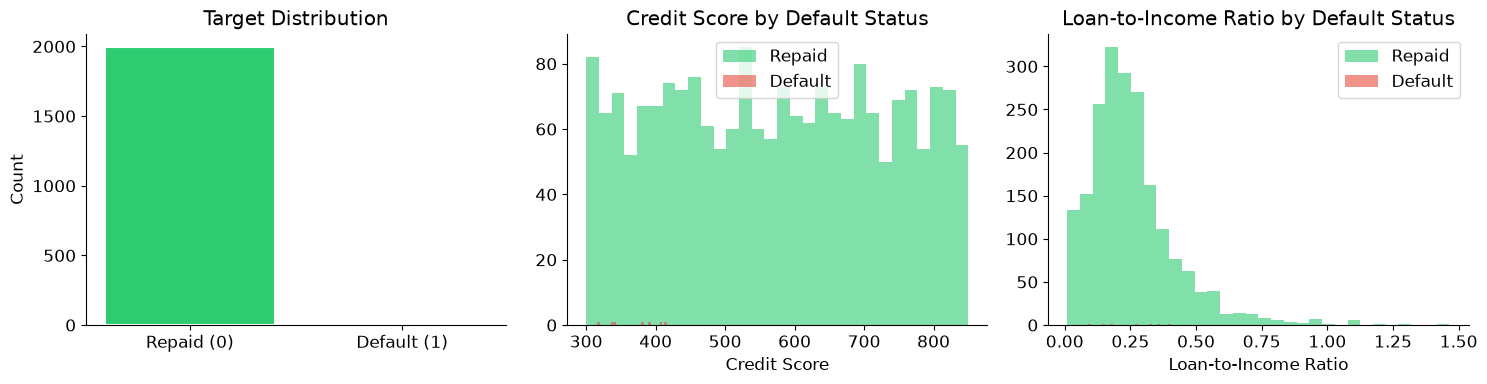

In [3]:
# ── Quick EDA ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(['Repaid (0)', 'Default (1)'],
            df['default'].value_counts().sort_index(),
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('Count')

for label, color in [(0,'#2ecc71'), (1,'#e74c3c')]:
    axes[1].hist(df[df['default']==label]['credit_score'],
                 bins=30, alpha=0.6, color=color,
                 label='Default' if label else 'Repaid')
axes[1].set_title('Credit Score by Default Status')
axes[1].set_xlabel('Credit Score')
axes[1].legend()

for label, color in [(0,'#2ecc71'), (1,'#e74c3c')]:
    axes[2].hist(df[df['default']==label]['loan_to_income'],
                 bins=30, alpha=0.6, color=color,
                 label='Default' if label else 'Repaid')
axes[2].set_title('Loan-to-Income Ratio by Default Status')
axes[2].set_xlabel('Loan-to-Income Ratio')
axes[2].legend()

plt.tight_layout()
plt.show()


In [4]:
# ── Encode categorical feature & prepare X, y ─────────────────────────────────
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['loan_purpose'], drop_first=False)

FEATURES = [c for c in df_model.columns if c != 'default']
X = df_model[FEATURES]
y = df_model['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} rows')
print(f'Test set     : {X_test.shape[0]} rows')
print(f'Features     : {X_train.shape[1]}')


Training set : 1600 rows
Test set     : 400 rows
Features     : 17


---
## 🧠 Section 2 — What is a Decision Tree?

### The big picture — a flowchart of yes/no questions

Imagine you are a loan officer at a bank. You have seen thousands of applications
and you develop an intuition that sounds like:

> *If the credit score is below 580 AND the loan-to-income ratio is above 0.4,
> I almost always see a default.*
> *But if the credit score is above 700, I almost never see one.*

That **mental rulebook** is exactly what a Decision Tree learns — automatically, from data.

```
                    [credit_score <= 580?]
                   /                     \
                 YES                      NO
                 /                          \
   [loan_to_income > 0.4?]         [interest_rate > 18?]
      /            \                  /              \
    YES             NO              YES               NO
    /                 \             /                  \
🔴 DEFAULT         🟡 MAYBE     🟡 MAYBE           🟢 REPAID
```

### Terminology

| Term | Meaning |
|---|---|
| **Root node** | The very first question (top of the tree) |
| **Internal node** | Any node that asks a question and splits |
| **Leaf node** | Terminal node — gives the final prediction |
| **Branch / Edge** | The YES or NO path out of a node |
| **Depth** | How many levels deep the tree goes |
| **Split** | The question used to divide data at a node |

### How does the tree decide WHICH question to ask first?

The algorithm needs a mathematical way to measure:
> **Which split makes the resulting groups as pure as possible?**

A **pure** group means everyone in it belongs to the same class.  
An **impure** group is a mix of defaulters and non-defaulters.

This is where **Gini Impurity** and **Entropy** come in.


---
## 📐 Section 3 — Gini Impurity

### Definition

Gini Impurity measures how often a randomly chosen element from a set would be
incorrectly labelled if it were labelled according to the class distribution.

$$\text{Gini}(t) = 1 - \sum_{k=1}^{K} p_k^2$$

Where $p_k$ is the proportion of samples belonging to class $k$ at node $t$.

### Intuition with crisp examples

**Scenario A** — 10 applicants, ALL defaulted:  
$p_{default} = 1.0$, $p_{repaid} = 0.0$  
$\text{Gini} = 1 - (1.0^2 + 0.0^2) = 0$ → **Perfectly pure ✅**

**Scenario B** — 10 applicants, exactly 5 defaulted:  
$p_{default} = 0.5$, $p_{repaid} = 0.5$  
$\text{Gini} = 1 - (0.5^2 + 0.5^2) = 0.5$ → **Maximum impurity ❌**

**Gini ranges from 0 (pure) to 0.5 (for binary classification).**


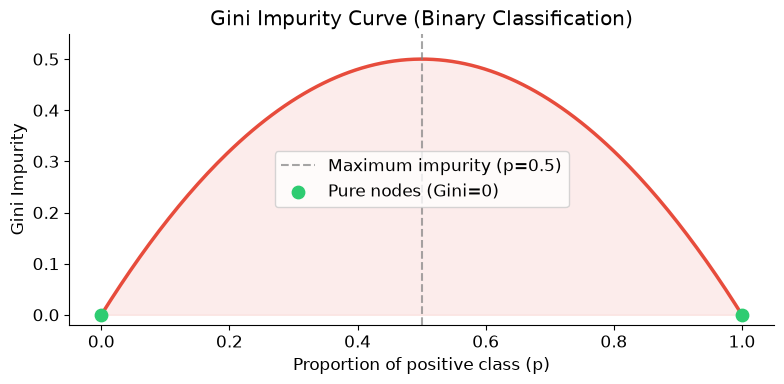

  Defaults | Non-defaults |  p_default |     Gini
--------------------------------------------------
         0 |           10 |       0.00 |   0.0000
         2 |            8 |       0.20 |   0.3200
         5 |            5 |       0.50 |   0.5000
         8 |            2 |       0.80 |   0.3200
        10 |            0 |       1.00 |   0.0000


In [5]:
# ── Gini Impurity — visualized ─────────────────────────────────────────────────

def gini_impurity(p_positive):
    p_negative = 1 - p_positive
    return 1 - (p_positive**2 + p_negative**2)

p_values   = np.linspace(0, 1, 200)
gini_values = [gini_impurity(p) for p in p_values]

plt.figure(figsize=(8, 4))
plt.plot(p_values, gini_values, color='#e74c3c', linewidth=2.5)
plt.fill_between(p_values, gini_values, alpha=0.1, color='#e74c3c')
plt.axvline(0.5, linestyle='--', color='gray', alpha=0.7, label='Maximum impurity (p=0.5)')
plt.scatter([0, 1], [0, 0], s=80, color='#2ecc71', zorder=5, label='Pure nodes (Gini=0)')
plt.xlabel('Proportion of positive class (p)')
plt.ylabel('Gini Impurity')
plt.title('Gini Impurity Curve (Binary Classification)')
plt.legend()
plt.ylim(-0.02, 0.55)
plt.tight_layout()
plt.show()

# Print example values
print(f'{"Defaults":>10} | {"Non-defaults":>12} | {"p_default":>10} | {"Gini":>8}')
print('-' * 50)
for defaults, total in [(0,10),(2,10),(5,10),(8,10),(10,10)]:
    p = defaults / total
    print(f'{defaults:>10} | {total-defaults:>12} | {p:>10.2f} | {gini_impurity(p):>8.4f}')


### Weighted Gini for a Split

When we split a node into two children, the **Gini of the split** is a weighted average:

$$\text{Gini}_{split} = \frac{N_L}{N} \cdot \text{Gini}(L) + \frac{N_R}{N} \cdot \text{Gini}(R)$$

The CART algorithm tries every possible feature and every possible threshold,
computes this weighted Gini for each candidate split, and **chooses the one that
gives the lowest weighted Gini** — i.e., the purest children.


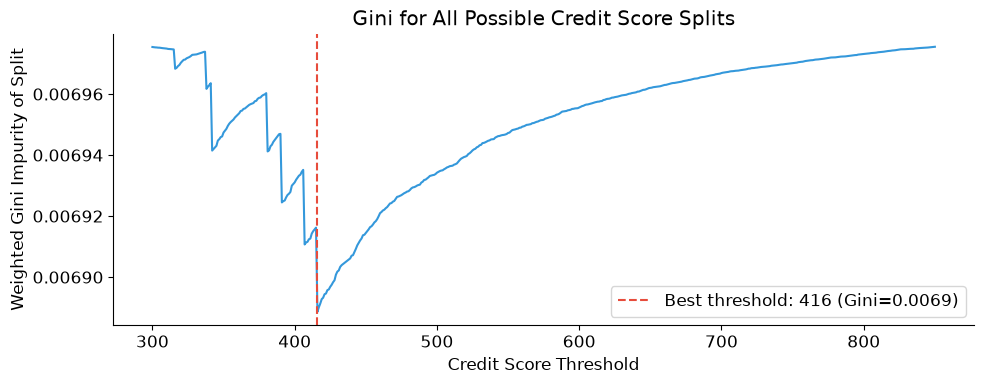

Best credit score split: credit_score <= 416
Weighted Gini at this split: 0.0069


In [6]:
# ── Manually computing Gini for a split — sweep over credit score thresholds ───

def weighted_gini(y_left, y_right):
    n = len(y_left) + len(y_right)
    def node_gini(y):
        if len(y) == 0: return 0
        p = y.mean()
        return 1 - p**2 - (1-p)**2
    return (len(y_left)/n)*node_gini(y_left) + (len(y_right)/n)*node_gini(y_right)

thresholds  = sorted(df['credit_score'].unique())
gini_scores = []
for thresh in thresholds:
    mask = df['credit_score'] <= thresh
    g = weighted_gini(df.loc[mask, 'default'].values,
                      df.loc[~mask, 'default'].values)
    gini_scores.append(g)

best_thresh = thresholds[np.argmin(gini_scores)]
best_gini   = min(gini_scores)

plt.figure(figsize=(10, 4))
plt.plot(thresholds, gini_scores, color='#3498db', linewidth=1.5)
plt.axvline(best_thresh, color='#e74c3c', linestyle='--',
            label=f'Best threshold: {best_thresh} (Gini={best_gini:.4f})')
plt.xlabel('Credit Score Threshold')
plt.ylabel('Weighted Gini Impurity of Split')
plt.title('Gini for All Possible Credit Score Splits')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best credit score split: credit_score <= {best_thresh}')
print(f'Weighted Gini at this split: {best_gini:.4f}')


---
## 📊 Section 4 — Entropy & Information Gain

### Entropy — borrowing from Information Theory

Entropy measures **disorder** or **uncertainty** in a set (Claude Shannon, 1948).

$$\text{Entropy}(t) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

- Entropy = **0** → completely pure (no uncertainty)
- Entropy = **1** → maximum disorder (50/50 split in binary case)

**Real-world analogy:**  
Flipping a fair coin — you have no idea what is coming. High entropy.  
Flipping a coin that always lands heads — you are certain. Zero entropy.

### Information Gain

Information Gain measures how much a split **reduces entropy**:

$$\text{IG}(t, s) = \text{Entropy}(t) - \left[ \frac{N_L}{N} \cdot \text{Entropy}(L) + \frac{N_R}{N} \cdot \text{Entropy}(R) \right]$$

**The tree picks the split with the highest Information Gain.**

### Gini vs Entropy — which should you use?

| | Gini | Entropy |
|---|---|---|
| **Speed** | Faster (no log computation) | Slightly slower |
| **Default in sklearn** | ✅ Yes | Set `criterion='entropy'` |
| **Practical difference** | Results are usually very similar | Results are usually very similar |

> In practice: **start with Gini**. Switch to entropy if you have severe class imbalance.


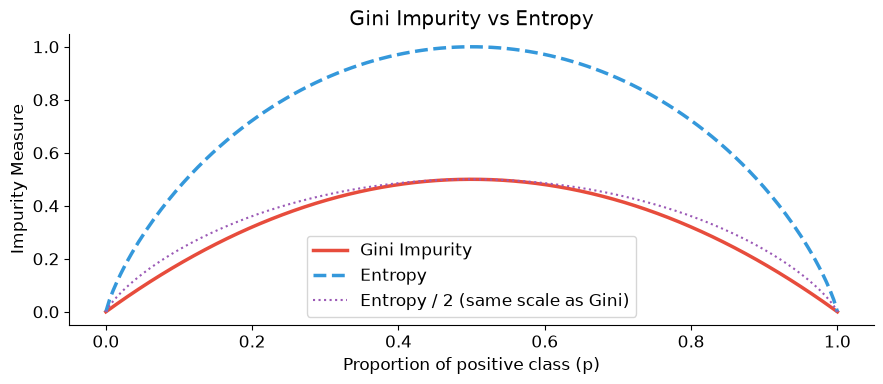

Key observation: The two curves have very similar shapes.
This is why Gini and Entropy usually produce almost identical trees.


In [8]:
# ── Entropy function ──────────────────────────────────────────────────────────
def entropy(p_positive):
    if p_positive == 0 or p_positive == 1:
        return 0
    p_neg = 1 - p_positive
    return -(p_positive * np.log2(p_positive) + p_neg * np.log2(p_neg))

entropy_values = [entropy(p) for p in p_values]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(p_values, gini_values,   color='#e74c3c', linewidth=2.5, label='Gini Impurity')
ax.plot(p_values, entropy_values, color='#3498db', linewidth=2.5,
        linestyle='--', label='Entropy')
ax.plot(p_values, [e/2 for e in entropy_values], color='#9b59b6', linewidth=1.5,
        linestyle=':', label='Entropy / 2 (same scale as Gini)')
ax.set_xlabel('Proportion of positive class (p)')
ax.set_ylabel('Impurity Measure')
ax.set_title('Gini Impurity vs Entropy')
ax.legend()
plt.tight_layout()
plt.show()

print('Key observation: The two curves have very similar shapes.')
print('This is why Gini and Entropy usually produce almost identical trees.')


In [10]:
# ── Manual Information Gain calculation ───────────────────────────────────────

def node_entropy(y):
    if len(y) == 0: return 0
    p = y.mean()
    return entropy(p)

def information_gain(y_parent, y_left, y_right):
    n = len(y_parent)
    parent_ent = node_entropy(y_parent)
    weighted   = (len(y_left)/n)*node_entropy(y_left) + (len(y_right)/n)*node_entropy(y_right)
    return parent_ent - weighted

y_all = df['default'].values

# Split A: credit_score <= 580
mask_A = df['credit_score'] <= 580
ig_A   = information_gain(y_all, y_all[mask_A], y_all[~mask_A])

# Split B: loan_to_income > 0.3
mask_B = df['loan_to_income'] > 0.3
ig_B   = information_gain(y_all, y_all[mask_B], y_all[~mask_B])

print('=' * 55)
print(f'Parent node entropy         : {node_entropy(y_all):.4f}')
print('=' * 55)
print(f'Split A: credit_score <= 580')
print(f'  Left  entropy             : {node_entropy(y_all[mask_A]):.4f}  (n={mask_A.sum()})')
print(f'  Right entropy             : {node_entropy(y_all[~mask_A]):.4f}  (n={(~mask_A).sum()})')
print(f'  Information Gain          : {ig_A:.4f}')
print('=' * 55)
print(f'Split B: loan_to_income > 0.3')
print(f'  Left  entropy             : {node_entropy(y_all[~mask_B]):.4f}  (n={(~mask_B).sum()})')
print(f'  Right entropy             : {node_entropy(y_all[mask_B]):.4f}  (n={mask_B.sum()})')
print(f'  Information Gain          : {ig_B:.4f}')
print('=' * 55)
winner = 'Split A (credit_score)' if ig_A > ig_B else 'Split B (loan_to_income)'
print(f'Winner: {winner} (higher IG)')


Parent node entropy         : 0.0336
Split A: credit_score <= 580
  Left  entropy             : 0.0587  (n=1031)
  Right entropy             : 0.0000  (n=969)
  Information Gain          : 0.0034
Split B: loan_to_income > 0.3
  Left  entropy             : 0.0278  (n=1428)
  Right entropy             : 0.0473  (n=572)
  Information Gain          : 0.0002
Winner: Split A (credit_score) (higher IG)


---
## 🌲 Section 5 — The CART Algorithm

**CART** stands for **Classification and Regression Trees** — it is the algorithm sklearn uses.

### How CART builds a tree (step by step)

```
CART(node, data):
1. If stopping condition met  →  make this node a LEAF, return
2. For every feature f:
      For every threshold t in f's values:
          Compute weighted Gini of split (f <= t) vs (f > t)
3. Pick (f*, t*) with the LOWEST weighted Gini
4. Split data into Left (f <= t*) and Right (f > t*)
5. Recursively call CART(left_node, left_data)
                  CART(right_node, right_data)
```

### Stopping conditions

- The node is **pure** (Gini = 0)
- We have reached the **maximum depth** (`max_depth`)
- A node has fewer than `min_samples_split` samples
- A resulting leaf would have fewer than `min_samples_leaf` samples

### CART is greedy — an important limitation

CART picks the **locally optimal** split at each step. It does not look ahead.
The tree found might not be globally optimal — but finding the true global
optimum is NP-hard, so greedy is the practical standard.


In [11]:
# ── Build an unconstrained (fully grown) tree ────────────────────────────────
tree_full = DecisionTreeClassifier(random_state=42)  # no limits at all
tree_full.fit(X_train, y_train)

train_acc = tree_full.score(X_train, y_train)
test_acc  = tree_full.score(X_test,  y_test)

print('Unconstrained (fully grown) tree:')
print(f'  Max depth reached : {tree_full.get_depth()}')
print(f'  Number of leaves  : {tree_full.get_n_leaves()}')
print(f'  Train accuracy    : {train_acc:.4f}')
print(f'  Test  accuracy    : {test_acc:.4f}')
print()
print('Notice the gap between train and test accuracy.')
print('This is OVERFITTING — the tree has memorized the training data.')


Unconstrained (fully grown) tree:
  Max depth reached : 7
  Number of leaves  : 14
  Train accuracy    : 1.0000
  Test  accuracy    : 0.9950

Notice the gap between train and test accuracy.
This is OVERFITTING — the tree has memorized the training data.


---
## 🖼️ Section 6 — Tree Visualization with `plot_tree`

One of the biggest advantages of decision trees: you can **see** the model.

We use a shallow tree (depth=3) to keep it legible. Each node in the visualization shows:
- The **split condition** (e.g., `credit_score <= 580`)
- **Gini impurity** at that node
- **Number of samples** at that node
- **Class distribution** — `value: [n_repaid, n_default]`
- **Predicted class** at that node (majority class wins)

**Node color** indicates predicted class: orange = default, blue/white = repaid.  
**Darker colour** = purer node (more confident prediction).


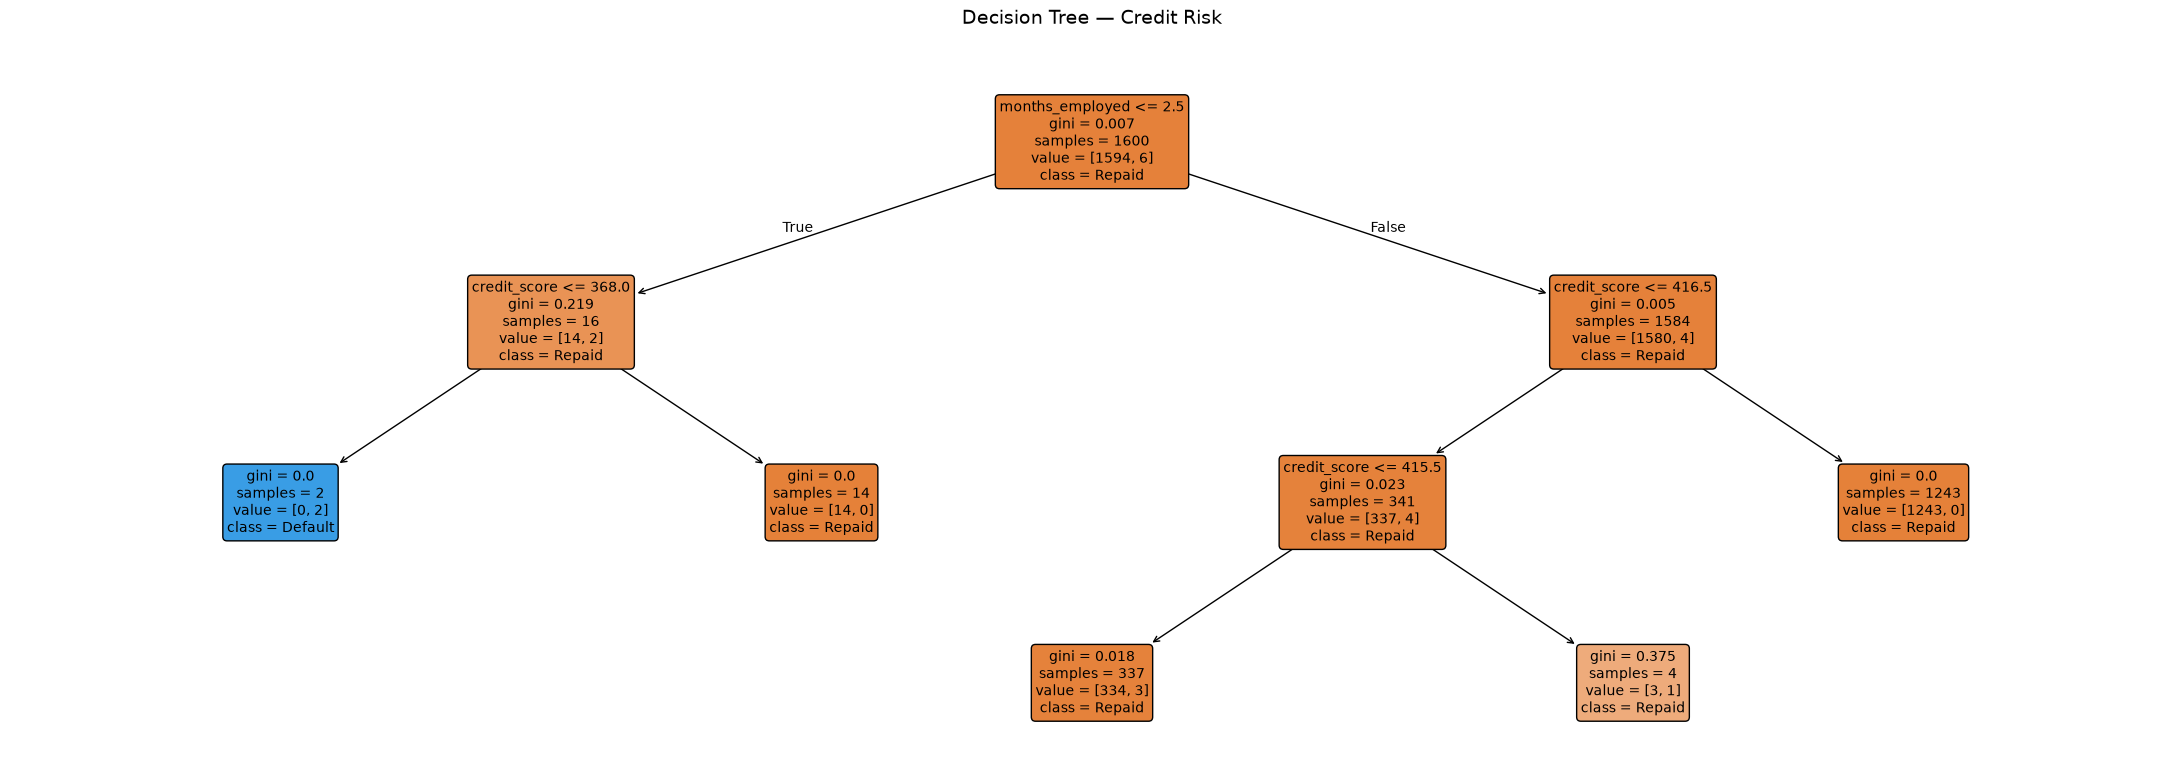

Tree in text form:
|--- months_employed <= 2.50
|   |--- credit_score <= 368.00
|   |   |--- class: 1
|   |--- credit_score >  368.00
|   |   |--- class: 0
|--- months_employed >  2.50
|   |--- credit_score <= 416.50
|   |   |--- credit_score <= 415.50
|   |   |   |--- class: 0
|   |   |--- credit_score >  415.50
|   |   |   |--- class: 0
|   |--- credit_score >  416.50
|   |   |--- class: 0



In [12]:
# ── Build a shallow tree for visualization ────────────────────────────────────
tree_viz = DecisionTreeClassifier(max_depth = 3, random_state=42)
tree_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    tree_viz,
    feature_names=FEATURES,
    class_names=['Repaid', 'Default'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False
)
ax.set_title('Decision Tree — Credit Risk', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print('Tree in text form:')
print(export_text(tree_viz, feature_names=FEATURES, max_depth=3))


In [13]:
# ── Trace a single prediction through the tree ───────────────────────────────
sample = X_test.iloc[[0]]
pred   = tree_viz.predict(sample)[0]
prob   = tree_viz.predict_proba(sample)[0]

print('Sample applicant profile:')
print(sample[['credit_score','loan_to_income','interest_rate',
              'months_employed','num_loans']].to_string(index=False))
print(f'\nModel prediction : {"DEFAULT" if pred==1 else "REPAID"}')
print(f'Probability      : P(repaid)={prob[0]:.3f}  P(default)={prob[1]:.3f}')
print(f'Actual outcome   : {"DEFAULT" if y_test.iloc[0]==1 else "REPAID"}')


Sample applicant profile:
 credit_score  loan_to_income  interest_rate  months_employed  num_loans
          730          0.2987          21.57              257          1

Model prediction : REPAID
Probability      : P(repaid)=1.000  P(default)=0.000
Actual outcome   : REPAID


---
## ✂️ Section 7 — Controlling Tree Growth (Pre-Pruning)

### The Overfitting Problem

A fully grown tree will:
- Create leaves with just 1 or 2 samples
- Learn noise in the training data as if it were a real pattern
- Generalize poorly to new data

**Pre-pruning** = stopping the tree from growing too deep **during** training.

### Key hyperparameters

| Parameter | What it controls | Effect of increasing |
|---|---|---|
| `max_depth` | Maximum levels deep | More complex tree |
| `min_samples_split` | Min samples needed to attempt a split | Simpler tree |
| `min_samples_leaf` | Min samples required in any leaf | Simpler tree |
| `min_impurity_decrease` | Min Gini improvement required to split | Simpler tree |


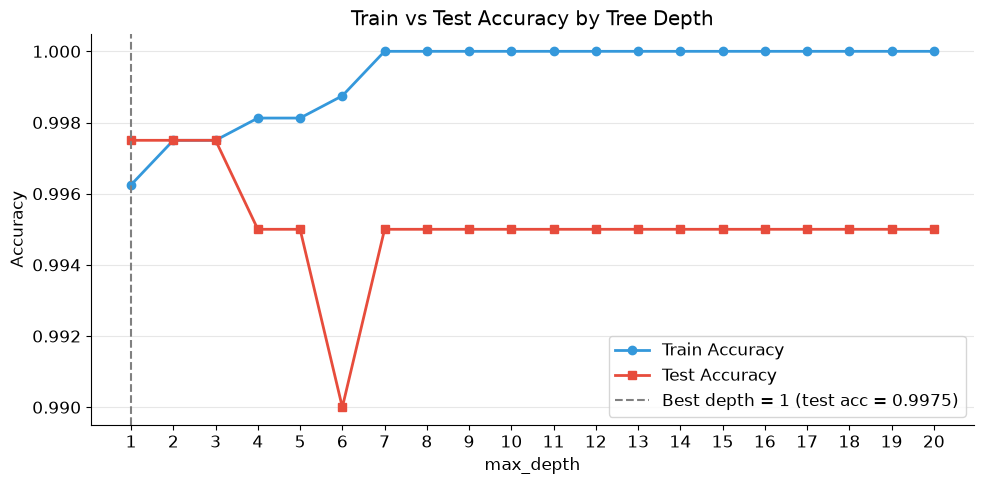

Sweet spot: depth ~ 1
Deeper than this → train keeps rising but test stagnates or drops (overfitting)


In [14]:
# ── Effect of max_depth on train vs test accuracy ─────────────────────────────
depths       = range(1, 21)
train_scores = []
test_scores  = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

best_depth = list(depths)[np.argmax(test_scores)]
best_test  = max(test_scores)

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'o-', color='#3498db', label='Train Accuracy', linewidth=2)
plt.plot(depths, test_scores,  's-', color='#e74c3c', label='Test Accuracy',  linewidth=2)
plt.axvline(best_depth, linestyle='--', color='gray',
            label=f'Best depth = {best_depth} (test acc = {best_test:.4f})')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by Tree Depth')
plt.legend()
plt.xticks(depths)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Sweet spot: depth ~ {best_depth}')
print('Deeper than this → train keeps rising but test stagnates or drops (overfitting)')


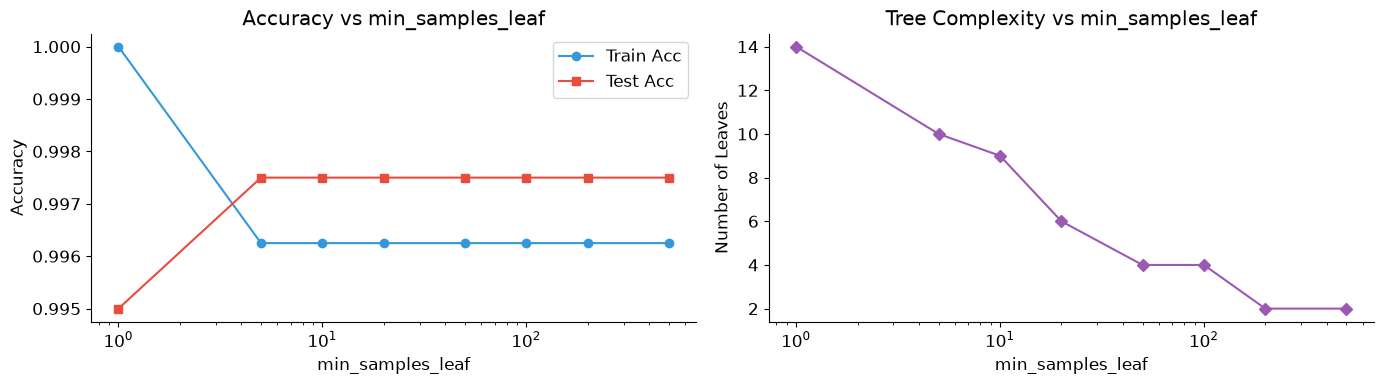

In [15]:
# ── Effect of min_samples_leaf ────────────────────────────────────────────────
leaf_sizes = [1, 5, 10, 20, 50, 100, 200, 500]
train_s, test_s, n_leaves = [], [], []

for msl in leaf_sizes:
    clf = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    clf.fit(X_train, y_train)
    train_s.append(clf.score(X_train, y_train))
    test_s.append(clf.score(X_test, y_test))
    n_leaves.append(clf.get_n_leaves())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.semilogx(leaf_sizes, train_s, 'o-', color='#3498db', label='Train Acc')
ax1.semilogx(leaf_sizes, test_s,  's-', color='#e74c3c', label='Test Acc')
ax1.set_xlabel('min_samples_leaf')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs min_samples_leaf')
ax1.legend()

ax2.semilogx(leaf_sizes, n_leaves, 'D-', color='#9b59b6')
ax2.set_xlabel('min_samples_leaf')
ax2.set_ylabel('Number of Leaves')
ax2.set_title('Tree Complexity vs min_samples_leaf')

plt.tight_layout()
plt.show()


---
## ✂️ Section 8 — Cost-Complexity Pruning (Post-Pruning)

### The idea

Pre-pruning stops early. **Post-pruning** grows a full tree first, then prunes
back branches that do not justify their complexity.

### The objective

For a subtree $T$, define the cost-complexity criterion:

$$R_\alpha(T) = R(T) + \alpha \cdot |T|$$

Where:
- $R(T)$ = misclassification rate of the tree on training data
- $|T|$ = number of leaf nodes (complexity measure)
- $\alpha$ = **complexity parameter** — penalty for each additional leaf

When $\alpha = 0$: no penalty → keep the full tree  
When $\alpha$ is large: heavy penalty → prune aggressively → simpler tree

Sklearn's `ccp_alpha` parameter directly controls this.

### Workflow
1. Use `cost_complexity_pruning_path()` to find all meaningful alpha values
2. Train a tree for each alpha
3. Pick the alpha with best cross-validated accuracy


Number of alpha values to evaluate: 4
Alpha range: [0.000000, 0.001242]


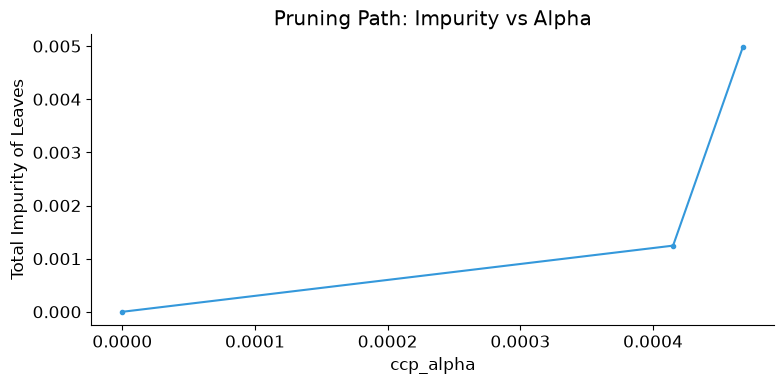

In [18]:
# ── Step 1: Get the pruning path ───────────────────────────────────────────────
clf_base = DecisionTreeClassifier(random_state=123)
path     = clf_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas  = path.ccp_alphas
impurities  = path.impurities

print(f'Number of alpha values to evaluate: {len(ccp_alphas)}')
print(f'Alpha range: [{ccp_alphas[0]:.6f}, {ccp_alphas[-1]:.6f}]')

plt.figure(figsize=(8, 4))
plt.plot(ccp_alphas[:-1], impurities[:-1], marker='o', markersize=3,
         color='#3498db', linewidth=1.5)
plt.xlabel('ccp_alpha')
plt.ylabel('Total Impurity of Leaves')
plt.title('Pruning Path: Impurity vs Alpha')
plt.tight_layout()
plt.show()


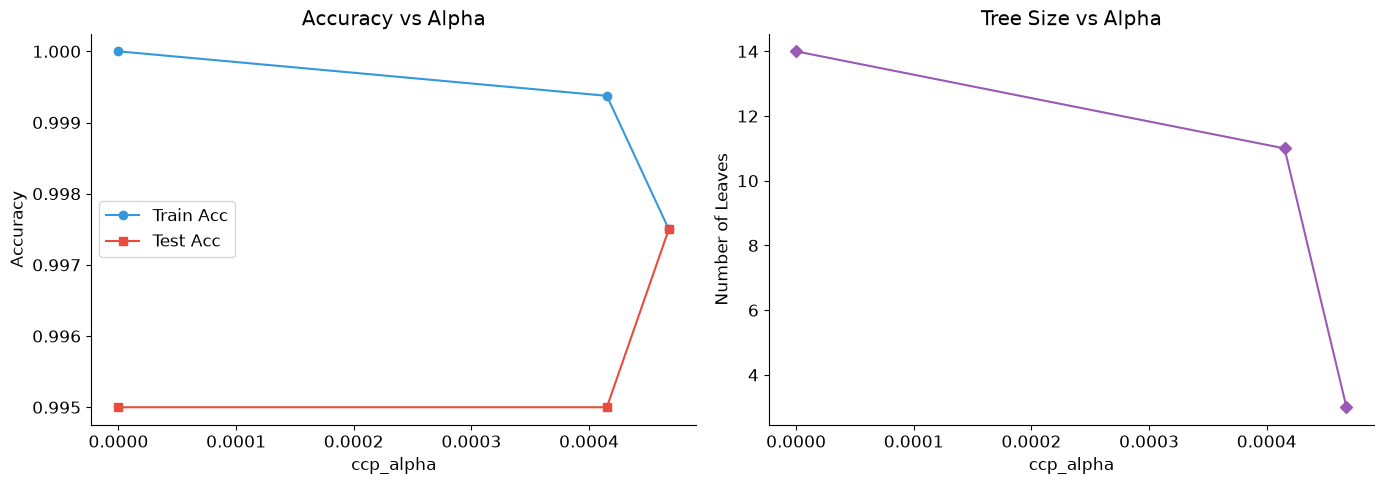

In [19]:
# ── Step 2: Train a tree for each alpha ───────────────────────────────────────
alphas_to_try = ccp_alphas[:-1]
clfs, train_s, test_s, leaf_counts = [], [], [], []

for alpha in alphas_to_try:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    clfs.append(clf)
    train_s.append(clf.score(X_train, y_train))
    test_s.append(clf.score(X_test,  y_test))
    leaf_counts.append(clf.get_n_leaves())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(alphas_to_try, train_s, 'o-', color='#3498db', label='Train Acc')
axes[0].plot(alphas_to_try, test_s,  's-', color='#e74c3c', label='Test Acc')
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Alpha')
axes[0].legend()

axes[1].plot(alphas_to_try, leaf_counts, 'D-', color='#9b59b6')
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Number of Leaves')
axes[1].set_title('Tree Size vs Alpha')

plt.tight_layout()
plt.show()


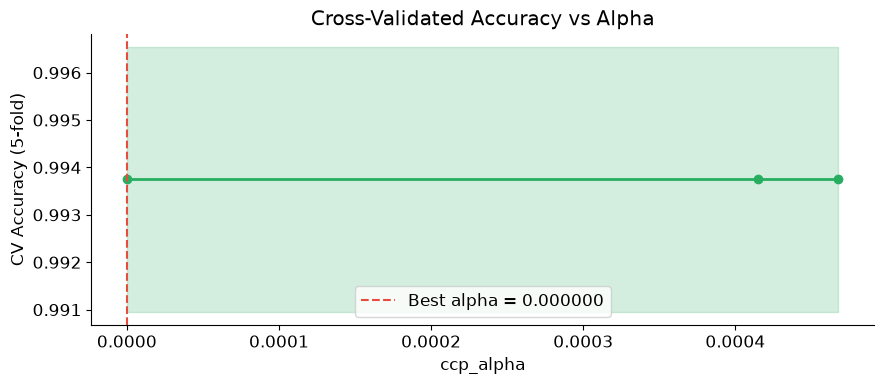

Final pruned tree:
  Depth   : 7
  Leaves  : 14
  Train   : 1.0000
  Test    : 0.9950


In [22]:
# ── Step 3: Cross-validated alpha selection (best practice) ───────────────────
cv_alphas     = ccp_alphas[:-1][:15]
cv_means, cv_stds = [], []

for alpha in cv_alphas:
    clf    = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means    = np.array(cv_means)
cv_stds     = np.array(cv_stds)
best_cv_idx   = np.argmax(cv_means)
best_cv_alpha = cv_alphas[best_cv_idx]

plt.figure(figsize=(9, 4))
plt.plot(cv_alphas, cv_means, 'o-', color='#27ae60', linewidth=2)
plt.fill_between(cv_alphas, cv_means - cv_stds, cv_means + cv_stds,
                 alpha=0.2, color='#27ae60')
plt.axvline(best_cv_alpha, linestyle='--', color='#e74c3c',
            label=f'Best alpha = {best_cv_alpha:.6f}')
plt.xlabel('ccp_alpha')
plt.ylabel('CV Accuracy (5-fold)')
plt.title('Cross-Validated Accuracy vs Alpha')
plt.legend()
plt.tight_layout()
plt.show()

# Train final pruned tree
tree_pruned = DecisionTreeClassifier(ccp_alpha=best_cv_alpha, random_state=42)
tree_pruned.fit(X_train, y_train)
print(f'Final pruned tree:')
print(f'  Depth   : {tree_pruned.get_depth()}')
print(f'  Leaves  : {tree_pruned.get_n_leaves()}')
print(f'  Train   : {tree_pruned.score(X_train, y_train):.4f}')
print(f'  Test    : {tree_pruned.score(X_test, y_test):.4f}')


---
## 🏆 Section 9 — Feature Importance

### What is feature importance in a Decision Tree?

At each internal node, the split reduces impurity.
**Feature importance = the total reduction in impurity (weighted by sample count)**
attributable to each feature, across all nodes where that feature was used.

$$\text{Importance}(f) = \sum_{\text{nodes where } f \text{ is used}} \frac{N_t}{N} \cdot \Delta\text{Gini}(t)$$

These values are then **normalised** to sum to 1.

### Real-world use for banks
- Understand which factors drive default risk
- Required for **model explainability** under RBI / MAS / Basel III compliance
- Identify redundant features to simplify the model

### ⚠️ A known limitation
Decision tree feature importance is **biased toward high-cardinality features**
(features with many unique values like `income`, `age`). These features have more
candidate split points and more opportunities to be chosen — even if not truly
more important. For robust importance, prefer **SHAP values** (covered in Session 45).


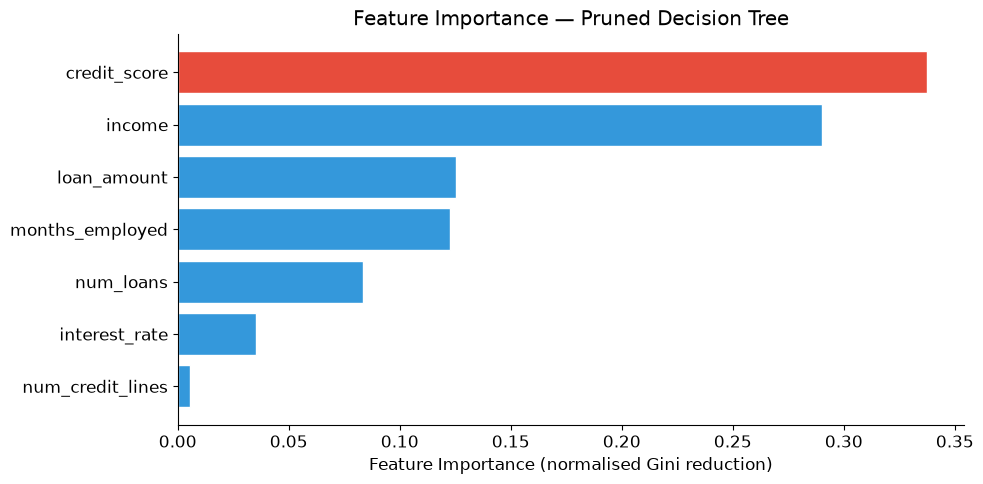

Top features by importance:
         feature  importance
    credit_score    0.337366
          income    0.290340
     loan_amount    0.125471
 months_employed    0.122763
       num_loans    0.083647
   interest_rate    0.035081
num_credit_lines    0.005333


In [23]:
# ── Feature Importance from the pruned tree ───────────────────────────────────
importances = tree_pruned.feature_importances_
feat_imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)
feat_imp_df = feat_imp_df[feat_imp_df['importance'] > 0].reset_index(drop=True)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(feat_imp_df))]
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'],
         color=colors, edgecolor='white')
plt.xlabel('Feature Importance (normalised Gini reduction)')
plt.title('Feature Importance — Pruned Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top features by importance:')
print(feat_imp_df.head(8).to_string(index=False))


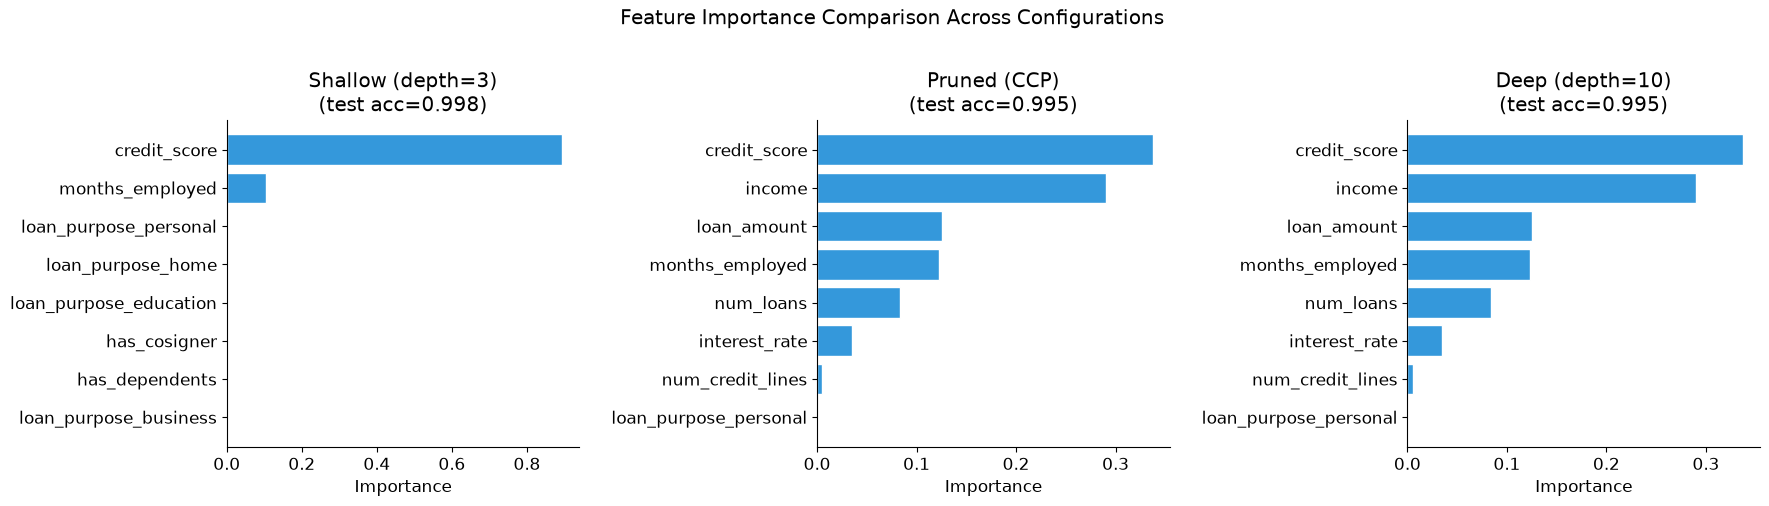

In [24]:
# ── Compare feature importance across different tree configurations ───────────
configs = {
    'Shallow (depth=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Pruned (CCP)':      tree_pruned,
    'Deep (depth=10)':   DecisionTreeClassifier(max_depth=10, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, clf) in zip(axes, configs.items()):
    if name != 'Pruned (CCP)':
        clf.fit(X_train, y_train)
    imps    = clf.feature_importances_
    top_idx = np.argsort(imps)[::-1][:8]
    ax.barh([FEATURES[i] for i in top_idx[::-1]], imps[top_idx[::-1]],
            color='#3498db', edgecolor='white')
    ax.set_title(f'{name}\n(test acc={clf.score(X_test,y_test):.3f})')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison Across Configurations', y=1.01)
plt.tight_layout()
plt.show()


---
## 📈 Section 10 — Partial Dependence Plots (PDPs)

### Motivation

Feature importance tells you **which** features matter.  
A Partial Dependence Plot tells you **how** a feature affects the prediction
— its direction and shape.

### How PDPs work

To compute the PDP of feature $X_j$:
1. Pick a grid of values for $X_j$ (e.g., credit scores from 300 to 850)
2. For each grid value $v$:
   - Set $X_j = v$ for **all** training samples (override the real value)
   - Get the model predictions for all samples
   - **Average** the predictions — this is the partial dependence at $v$
3. Plot these averages — that is your PDP

### What PDPs show
- **Direction:** does the feature increase or decrease the probability of default?
- **Shape:** is the relationship linear, step-like, or flat at extremes?

### ⚠️ Limitation of PDPs
PDPs assume features are **independent**. If `credit_score` and `income` are
correlated, the PDP can show unrealistic combinations (e.g., very high income
+ very low credit score) that barely exist in real data. For correlated features,
prefer **ICE plots** or **SHAP** (covered in Session 45).


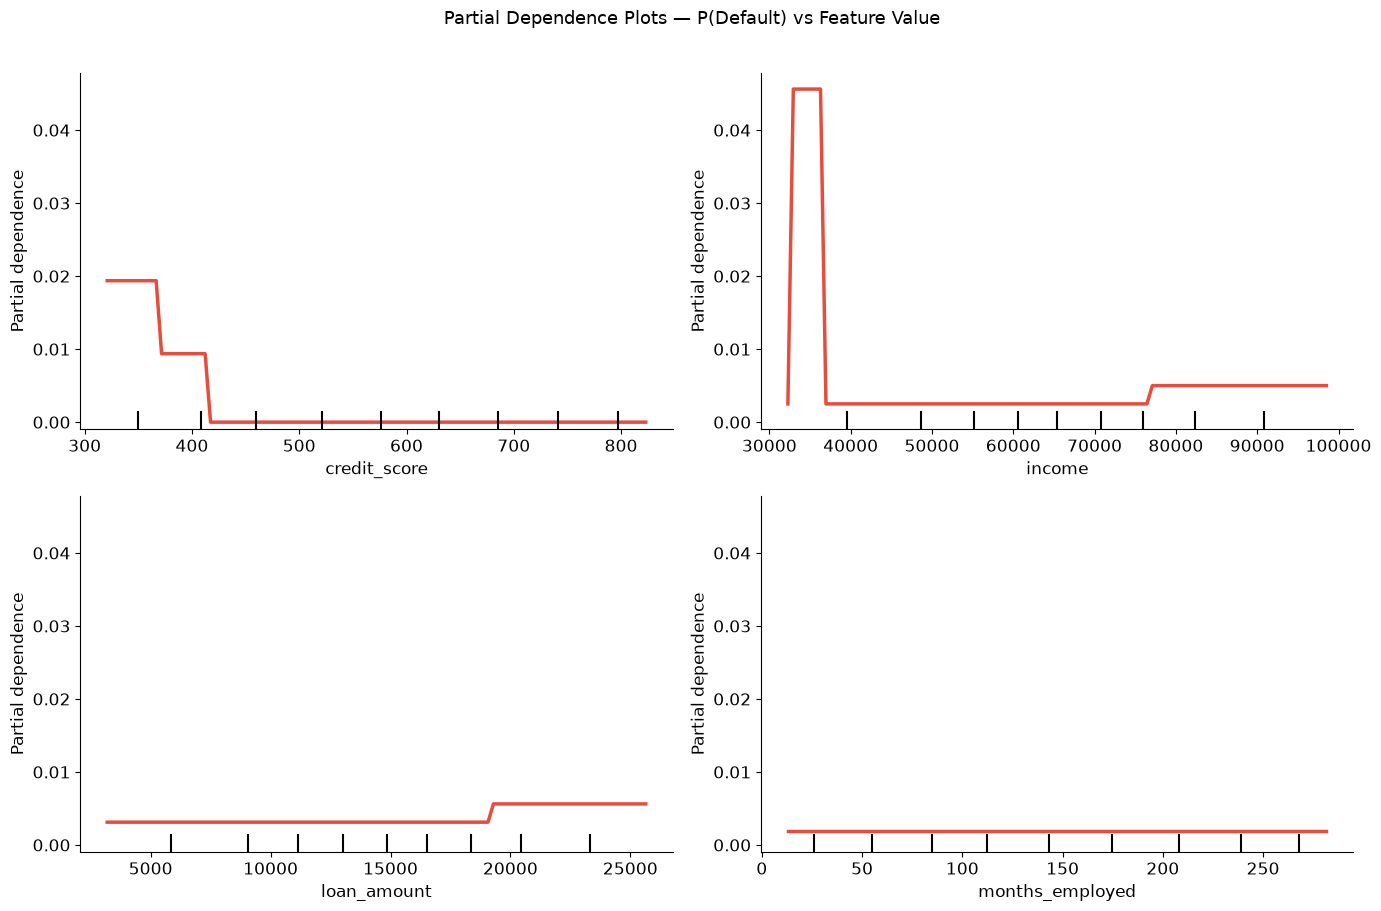

Reading the plots:
  Y-axis = average predicted probability of DEFAULT
  X-axis = feature value
  Downward slope for credit_score = higher score -> lower default risk
  Upward slope for loan_to_income = higher ratio -> higher default risk


In [32]:
# ── 1D Partial Dependence Plots — top 4 features ─────────────────────────────
top_features    = feat_imp_df['feature'].head(4).tolist()
top_feature_idx = [FEATURES.index(f) for f in top_features]

# Convert int32 columns to float for ICE plotting (otherwise it throws a warning)
X_train_ice = X_train.copy()
for col in X_train_ice.select_dtypes(include='int32').columns:
    X_train_ice[col] = X_train_ice[col].astype(float)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
PartialDependenceDisplay.from_estimator(
    tree_pruned,
    X_train_ice,
    features=top_feature_idx,
    feature_names=FEATURES,
    target=1,
    kind='average',
    ax=axes.ravel(),
    line_kw={'color': '#e74c3c', 'linewidth': 2.5},
)
plt.suptitle('Partial Dependence Plots — P(Default) vs Feature Value',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print('Reading the plots:')
print('  Y-axis = average predicted probability of DEFAULT')
print('  X-axis = feature value')
print('  Downward slope for credit_score = higher score -> lower default risk')
print('  Upward slope for loan_to_income = higher ratio -> higher default risk')


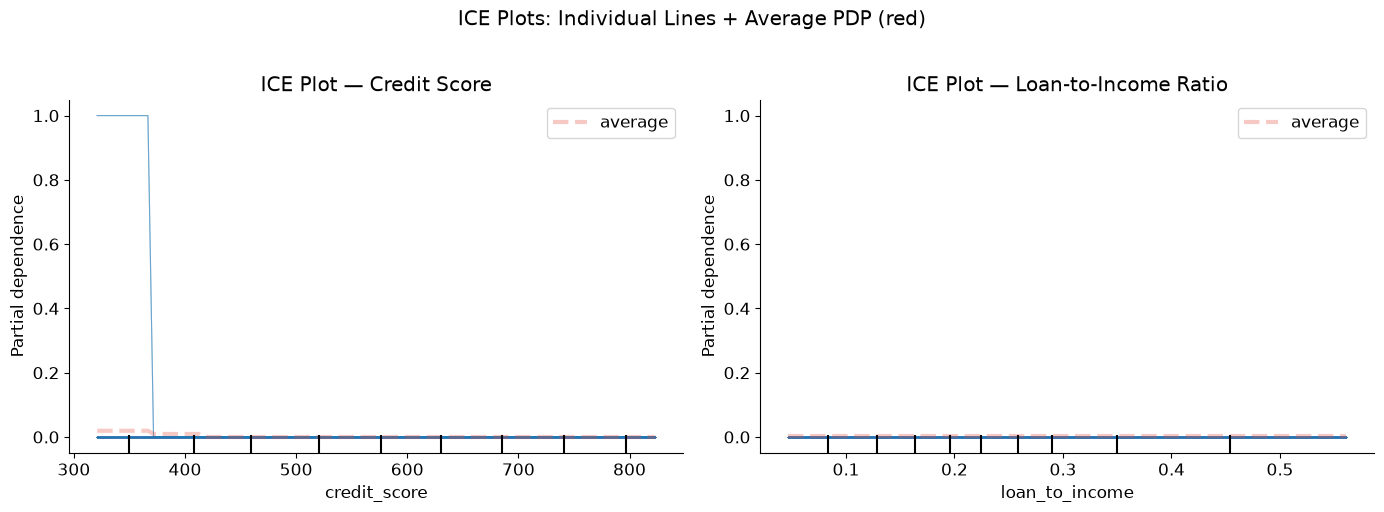

If ICE lines are parallel  -> no interaction with other features
If ICE lines cross/diverge -> interaction effects present


In [33]:
# ── ICE plots (Individual Conditional Expectation) ────────────────────────────
# ICE shows the PDP for each individual sample — reveals heterogeneity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
PartialDependenceDisplay.from_estimator(
    tree_pruned,
    X_train_ice,
    features=[FEATURES.index('credit_score'), FEATURES.index('loan_to_income')],
    feature_names=FEATURES,
    target=1,
    kind='both',
    subsample=100,
    ax=axes,
    line_kw={'alpha': 0.3, 'linewidth': 0.8},
    pd_line_kw={'color': '#e74c3c', 'linewidth': 3},
    random_state=42
)
axes[0].set_title('ICE Plot — Credit Score')
axes[1].set_title('ICE Plot — Loan-to-Income Ratio')
plt.suptitle('ICE Plots: Individual Lines + Average PDP (red)', y=1.02)
plt.tight_layout()
plt.show()

print('If ICE lines are parallel  -> no interaction with other features')
print('If ICE lines cross/diverge -> interaction effects present')


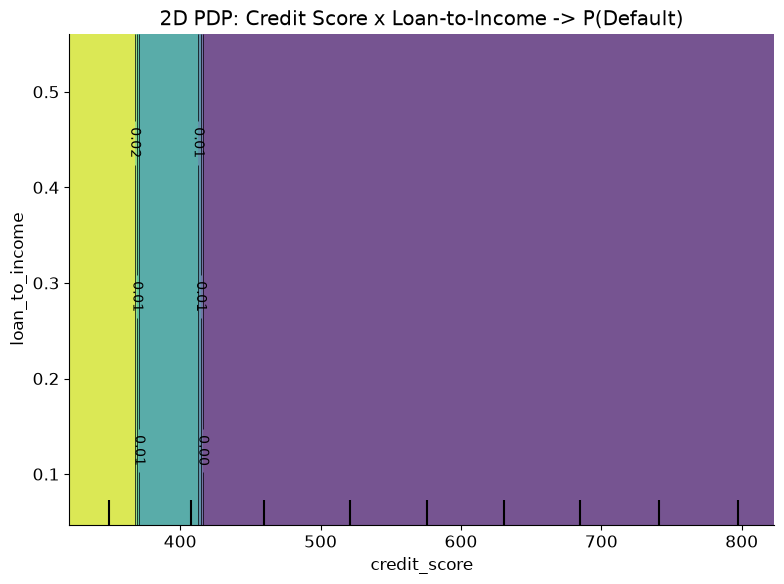

Darker = higher P(default)
Top-left corner (low credit score + high loan-to-income) = highest risk


In [34]:
# ── 2D PDP — interaction between two features ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    tree_pruned,
    X_train_ice,
    features=[(FEATURES.index('credit_score'), FEATURES.index('loan_to_income'))],
    feature_names=FEATURES,
    target=1,
    kind='average',
    ax=[ax]
)
ax.set_title('2D PDP: Credit Score x Loan-to-Income -> P(Default)')
plt.tight_layout()
plt.show()

print('Darker = higher P(default)')
print('Top-left corner (low credit score + high loan-to-income) = highest risk')


---
## 📊 Section 11 — Final Model Evaluation

Let us do a proper comparison of our three trees (shallow, pruned, unconstrained).


Model                   Train Acc   Test Acc      AUC   Depth   Leaves
----------------------------------------------------------------------
Shallow (depth=3)          0.9975     0.9975   0.8772       3        5
Pruned (CCP)               1.0000     0.9950   0.4987       7       14
Unconstrained              1.0000     0.9950   0.4987       7       14

Classification Report — Pruned Tree:
              precision    recall  f1-score   support

      Repaid       1.00      1.00      1.00       399
     Default       0.00      0.00      0.00         1

    accuracy                           0.99       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.99      0.99      0.99       400



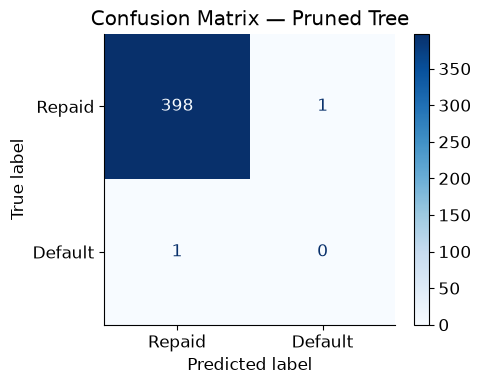

In [35]:
models = {
    'Shallow (depth=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Pruned (CCP)':      tree_pruned,
    'Unconstrained':     DecisionTreeClassifier(random_state=42),
}

print(f'{"Model":<22} {"Train Acc":>10} {"Test Acc":>10} {"AUC":>8} {"Depth":>7} {"Leaves":>8}')
print('-' * 70)
for name, clf in models.items():
    if name != 'Pruned (CCP)':
        clf.fit(X_train, y_train)
    tr  = clf.score(X_train, y_train)
    te  = clf.score(X_test, y_test)
    auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    print(f'{name:<22} {tr:>10.4f} {te:>10.4f} {auc:>8.4f} {clf.get_depth():>7} {clf.get_n_leaves():>8}')

print()
y_pred = tree_pruned.predict(X_test)
print('Classification Report — Pruned Tree:')
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Default']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Repaid', 'Default'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Pruned Tree')
plt.tight_layout()
plt.show()


---
## 🏋️ Exercise 1 — Guided (with TODO)

### Task: Sweep over `min_samples_split` as a pre-pruning strategy

Just like we swept over `max_depth`, now sweep over `min_samples_split` from 2 to 200.
Plot train and test accuracy. Identify the value giving the best test accuracy.

**Complete the TODOs below:**


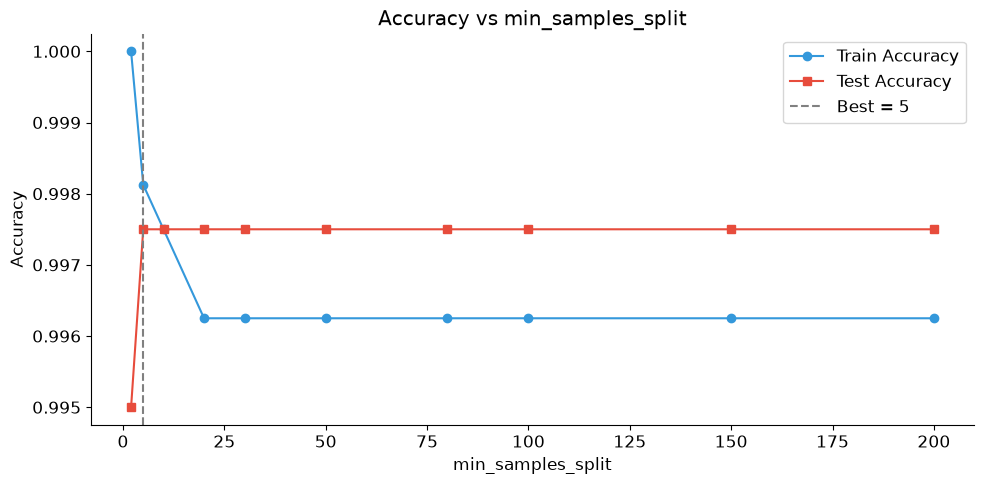

In [36]:
# EXERCISE 1 — Fill in the TODOs

split_values   = [2, 5, 10, 20, 30, 50, 80, 100, 150, 200]
ex1_train, ex1_test = [], []

for mss in split_values:
    # TODO 1: Create a DecisionTreeClassifier with min_samples_split=mss and random_state=42
    clf = DecisionTreeClassifier(min_samples_split=mss, random_state=42)

    # TODO 2: Fit on training data
    clf.fit(X_train, y_train)

    # TODO 3: Append train accuracy
    ex1_train.append(clf.score(X_train, y_train))

    # TODO 4: Append test accuracy
    ex1_test.append(clf.score(X_test, y_test))

# TODO 5: Find index of best test accuracy and get the corresponding split value
best_mss = split_values[np.argmax(ex1_test)]

# Plotting — no changes needed below
plt.figure(figsize=(10, 5))
plt.plot(split_values, ex1_train, 'o-', color='#3498db', label='Train Accuracy')
plt.plot(split_values, ex1_test,  's-', color='#e74c3c', label='Test Accuracy')
plt.axvline(best_mss, linestyle='--', color='gray', label=f'Best = {best_mss}')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.title('Accuracy vs min_samples_split')
plt.legend()
plt.tight_layout()
plt.show()


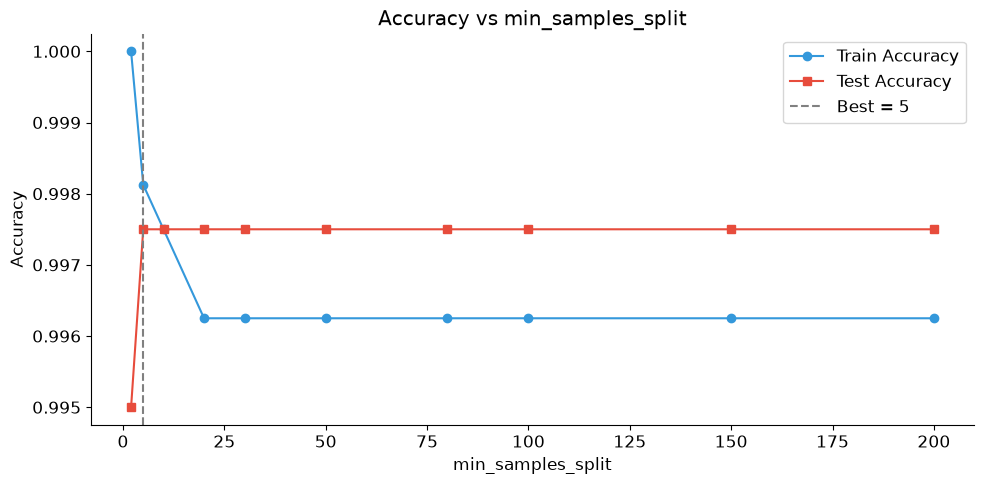

Best min_samples_split: 5
Best test accuracy    : 0.9975


In [37]:
# SOLUTION — Exercise 1

split_values   = [2, 5, 10, 20, 30, 50, 80, 100, 150, 200]
ex1_train, ex1_test = [], []

for mss in split_values:
    clf = DecisionTreeClassifier(min_samples_split=mss, random_state=42)  # TODO 1
    clf.fit(X_train, y_train)                                             # TODO 2
    ex1_train.append(clf.score(X_train, y_train))                        # TODO 3
    ex1_test.append(clf.score(X_test, y_test))                           # TODO 4

best_mss = split_values[np.argmax(ex1_test)]                             # TODO 5

plt.figure(figsize=(10, 5))
plt.plot(split_values, ex1_train, 'o-', color='#3498db', label='Train Accuracy')
plt.plot(split_values, ex1_test,  's-', color='#e74c3c', label='Test Accuracy')
plt.axvline(best_mss, linestyle='--', color='gray', label=f'Best = {best_mss}')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.title('Accuracy vs min_samples_split')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best min_samples_split: {best_mss}')
print(f'Best test accuracy    : {max(ex1_test):.4f}')


---
## 🏋️ Exercise 2 — Guided (with TODO)

### Task: Build a tree using `criterion='entropy'` and compare with Gini

1. Train a `DecisionTreeClassifier` with `criterion='entropy'` and `max_depth=4`
2. Train a matching Gini tree with `max_depth=4`
3. Visualize the entropy tree with `plot_tree`
4. Compare test accuracies
5. Print the top 5 features by importance from the entropy tree


Entropy tree test accuracy : 0.9975
Gini    tree test accuracy : 0.9950


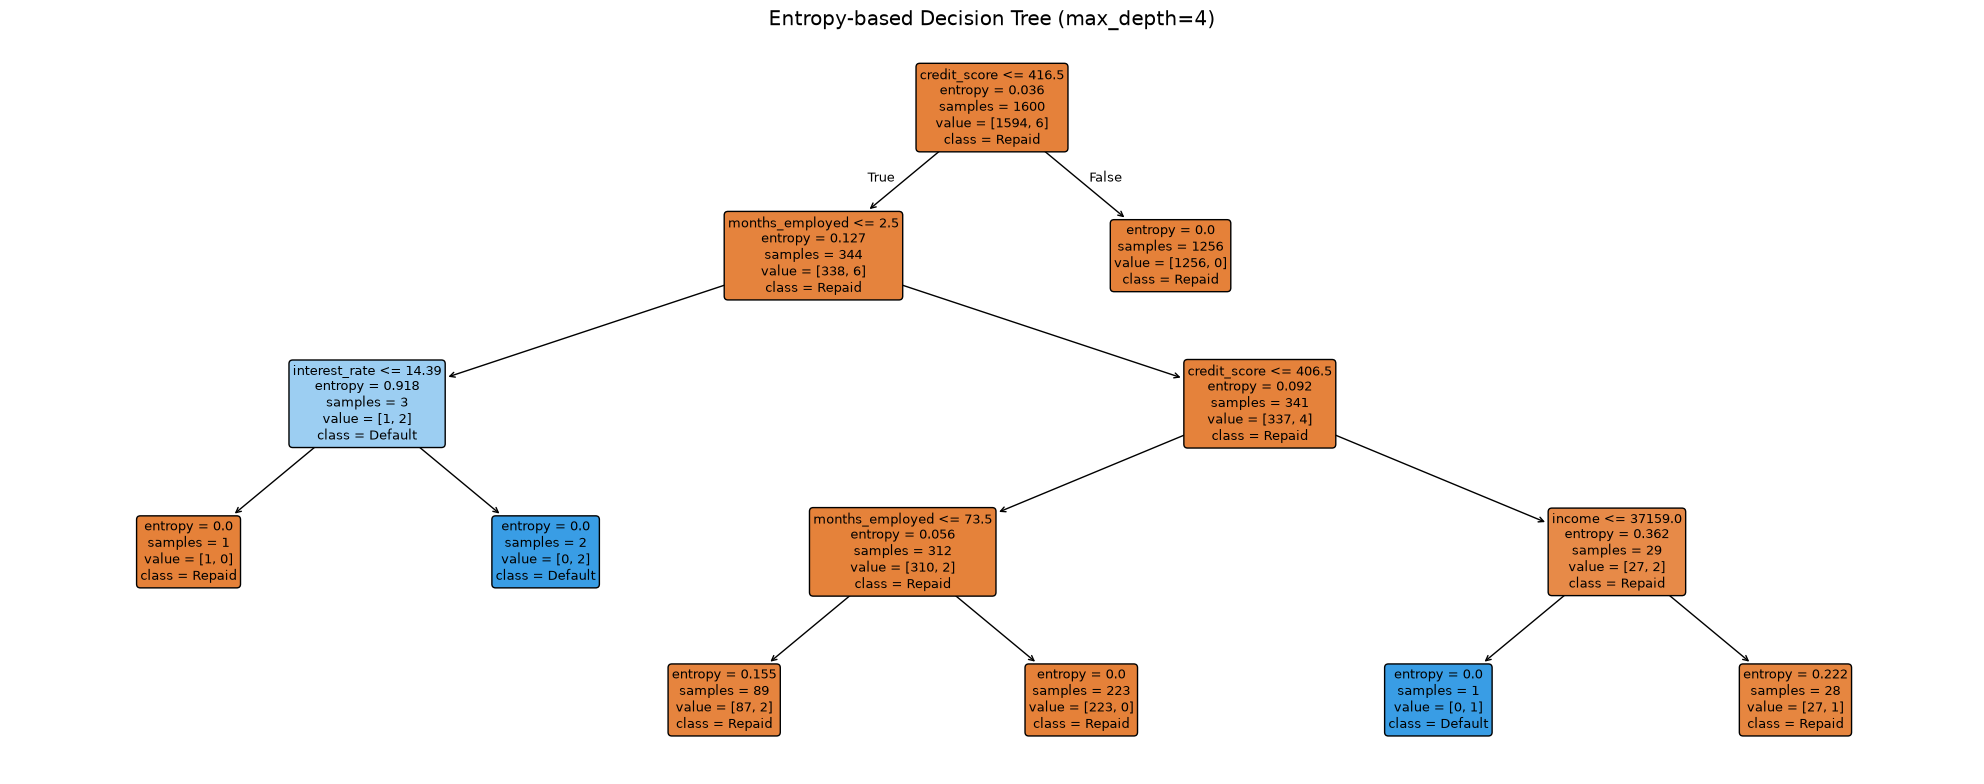

Top 5 features (entropy tree):
  credit_score              0.4548
  months_employed           0.3551
  income                    0.1157
  interest_rate             0.0745
  loan_purpose_personal     0.0000


In [38]:
# EXERCISE 2 — Fill in the TODOs

# TODO 1: Create and fit a DecisionTreeClassifier with criterion='entropy', max_depth=4
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
tree_entropy.fit(X_train, y_train)


# TODO 2: Create and fit a Gini tree with max_depth=4
tree_gini_d4 = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
tree_gini_d4.fit(X_train, y_train)

# TODO 3: Print test accuracy for both
print(f'Entropy tree test accuracy : {tree_entropy.score(X_test, y_test):.4f}')
print(f'Gini    tree test accuracy : {tree_gini_d4.score(X_test, y_test):.4f}')

# TODO 4: Visualise the entropy tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(tree_entropy, feature_names=FEATURES, class_names=['Repaid', 'Default'],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Entropy-based Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

# TODO 5: Print top 5 features from entropy tree
imps_entropy = tree_entropy.feature_importances_
top5_idx     = np.argsort(imps_entropy)[::-1][:5]
print('Top 5 features (entropy tree):')
for i in top5_idx:
    print(f'  {FEATURES[i]:<25} {imps_entropy[i]:.4f}')


Entropy tree test accuracy : 0.9975
Gini    tree test accuracy : 0.9950


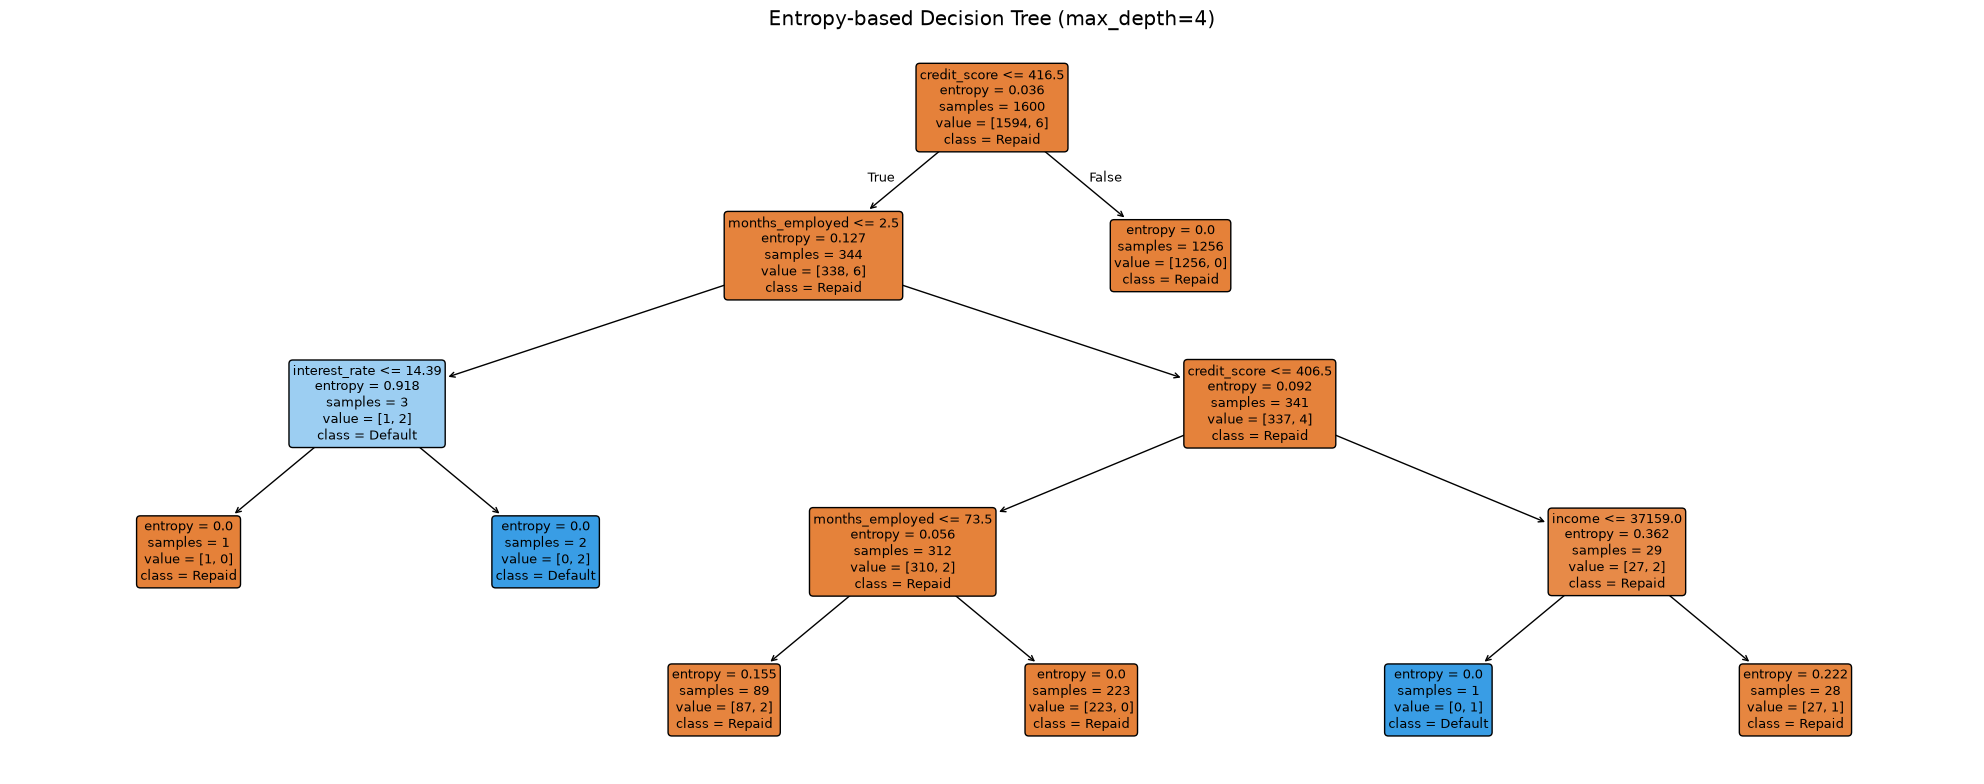

Top 5 features (entropy tree):
  credit_score              0.4548
  months_employed           0.3551
  income                    0.1157
  interest_rate             0.0745
  loan_purpose_personal     0.0000


In [39]:
# SOLUTION — Exercise 2

# TODO 1
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
tree_entropy.fit(X_train, y_train)

# TODO 2
tree_gini_d4 = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
tree_gini_d4.fit(X_train, y_train)

# TODO 3
print(f'Entropy tree test accuracy : {tree_entropy.score(X_test, y_test):.4f}')
print(f'Gini    tree test accuracy : {tree_gini_d4.score(X_test, y_test):.4f}')

# TODO 4
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(tree_entropy, feature_names=FEATURES, class_names=['Repaid', 'Default'],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Entropy-based Decision Tree (max_depth=4)')
plt.tight_layout()
plt.show()

# TODO 5
imps_entropy = tree_entropy.feature_importances_
top5_idx     = np.argsort(imps_entropy)[::-1][:5]
print('Top 5 features (entropy tree):')
for i in top5_idx:
    print(f'  {FEATURES[i]:<25} {imps_entropy[i]:.4f}')


---
## 🏋️ Exercise 3 — From Scratch

### Task: Full pipeline — Build, prune, evaluate, and explain a fraud detection tree

You are given a credit card transaction dataset below. Your job:

1. Explore the dataset (class balance, feature distributions)
2. Split into train/test (80/20, stratified)
3. Build an unconstrained tree. Report train and test accuracy
4. Use cost-complexity pruning to find the best `ccp_alpha` via 5-fold CV
5. Build the final pruned tree. Visualize it (use max_depth=3 in plot_tree)
6. Plot feature importance
7. Create PDPs for the top 2 most important features
8. Write 3-4 sentences interpreting your findings as if presenting to a risk team

**Tip:** Re-use code patterns from the lecture cells above.


In [40]:
# Fraud detection dataset — PROVIDED, do not modify
np.random.seed(99)
M = 3000

transaction_amount = np.random.exponential(200, M).clip(1, 5000).round(2)
hour_of_day        = np.random.randint(0, 24, M)
distance_from_home = np.random.exponential(30, M).clip(0, 500).round(1)
num_prev_txn_24h   = np.random.poisson(3, M)
is_foreign         = (np.random.rand(M) < 0.15).astype(int)
is_online          = (np.random.rand(M) < 0.4).astype(int)
card_age_months    = np.random.randint(1, 120, M)
account_balance    = np.random.normal(5000, 3000, M).clip(0, 50000).round(0)

log_odds_fraud = (
    -5.0
    + 0.003 * transaction_amount
    + 0.05  * np.maximum(0, hour_of_day - 22)
    + 0.01  * distance_from_home
    + 0.15  * num_prev_txn_24h
    + 1.5   * is_foreign
    + 0.8   * is_online
    - 0.01  * card_age_months
    - 0.0001* account_balance
)
prob_fraud = 1 / (1 + np.exp(-log_odds_fraud))
is_fraud   = (np.random.rand(M) < prob_fraud).astype(int)

df_fraud = pd.DataFrame({
    'transaction_amount':  transaction_amount,
    'hour_of_day':         hour_of_day,
    'distance_from_home':  distance_from_home,
    'num_prev_txn_24h':    num_prev_txn_24h,
    'is_foreign':          is_foreign,
    'is_online':           is_online,
    'card_age_months':     card_age_months,
    'account_balance':     account_balance,
    'is_fraud':            is_fraud
})

print('Fraud dataset shape:', df_fraud.shape)
print('Fraud rate: {:.1f}%'.format(df_fraud['is_fraud'].mean() * 100))
df_fraud.head()


Fraud dataset shape: (3000, 9)
Fraud rate: 3.0%


,transaction_amount,hour_of_day,distance_from_home,num_prev_txn_24h,is_foreign,is_online,card_age_months,account_balance,is_fraud
0,223.12,20,32.1,1,0,0,82,3619.0,0
1,133.92,4,83.2,5,0,0,5,6748.0,0
2,349.16,1,3.7,2,0,1,20,0.0,0
3,6.39,20,25.2,4,0,0,32,6364.0,0
4,330.10,23,45.0,1,1,1,17,6490.0,0


In [ ]:
# YOUR SOLUTION HERE
FRAUD_FEATURES = [c for c in df_fraud.columns if c != 'is_fraud']
Xf = df_fraud[FRAUD_FEATURES]
yf = df_fraud['is_fraud']

# Step 1: Explore



# Step 2: Train/test split



# Step 3: Unconstrained tree



# Step 4: CCP pruning



# Step 5: Final pruned tree + visualization



# Step 6: Feature importance



# Step 7: PDPs



# Step 8: Business interpretation (write as a comment)
#


In [ ]:
# SOLUTION — Exercise 3

FRAUD_FEATURES = [c for c in df_fraud.columns if c != 'is_fraud']
Xf = df_fraud[FRAUD_FEATURES]
yf = df_fraud['is_fraud']

# ── Step 1: Explore ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(['Legit','Fraud'], yf.value_counts().sort_index(),
            color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title('Class Distribution')
for label, color in [(0,'#2ecc71'),(1,'#e74c3c')]:
    axes[1].hist(df_fraud[df_fraud['is_fraud']==label]['transaction_amount'],
                 bins=30, alpha=0.6, color=color, label='Fraud' if label else 'Legit')
axes[1].set_title('Transaction Amount by Class')
axes[1].legend()
axes[2].scatter(df_fraud['distance_from_home'], df_fraud['transaction_amount'],
               c=df_fraud['is_fraud'], cmap='RdYlGn_r', alpha=0.3, s=10)
axes[2].set_xlabel('Distance from Home')
axes[2].set_ylabel('Transaction Amount')
axes[2].set_title('Distance vs Amount (red=fraud)')
plt.tight_layout()
plt.show()

# ── Step 2: Split ───────────────────────────────────────────────────────────
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    Xf, yf, test_size=0.2, random_state=42, stratify=yf)
print(f'Train: {Xf_train.shape[0]}  |  Test: {Xf_test.shape[0]}')

# ── Step 3: Unconstrained tree ──────────────────────────────────────────────
tree_f_full = DecisionTreeClassifier(random_state=42)
tree_f_full.fit(Xf_train, yf_train)
print(f'Unconstrained — Train: {tree_f_full.score(Xf_train, yf_train):.4f}  '
      f'Test: {tree_f_full.score(Xf_test, yf_test):.4f}')

# ── Step 4: CCP pruning ─────────────────────────────────────────────────────
path_f  = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(Xf_train, yf_train)
alphas_f = path_f.ccp_alphas[:-1:3][:15]
cv_means = []
for a in alphas_f:
    s = cross_val_score(DecisionTreeClassifier(ccp_alpha=a, random_state=42),
                        Xf_train, yf_train, cv=5)
    cv_means.append(s.mean())
best_fa = alphas_f[np.argmax(cv_means)]
plt.figure(figsize=(8, 4))
plt.plot(alphas_f, cv_means, 'o-', color='#27ae60')
plt.axvline(best_fa, linestyle='--', color='#e74c3c', label=f'Best alpha={best_fa:.5f}')
plt.xlabel('ccp_alpha'); plt.ylabel('CV Accuracy')
plt.title('CCP Pruning — Fraud Model'); plt.legend(); plt.tight_layout(); plt.show()

# ── Step 5: Final pruned tree ────────────────────────────────────────────────
tree_f_pruned = DecisionTreeClassifier(ccp_alpha=best_fa, random_state=42)
tree_f_pruned.fit(Xf_train, yf_train)
print(f'Pruned — Train: {tree_f_pruned.score(Xf_train, yf_train):.4f}  '
      f'Test: {tree_f_pruned.score(Xf_test, yf_test):.4f}  '
      f'AUC: {roc_auc_score(yf_test, tree_f_pruned.predict_proba(Xf_test)[:,1]):.4f}')
print(f'Depth: {tree_f_pruned.get_depth()}  Leaves: {tree_f_pruned.get_n_leaves()}')
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(tree_f_pruned, max_depth=3, feature_names=FRAUD_FEATURES,
          class_names=['Legit','Fraud'], filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Fraud Detection Tree (Pruned, shown to depth=3)')
plt.tight_layout(); plt.show()

# ── Step 6: Feature importance ───────────────────────────────────────────────
f_imps = pd.DataFrame({'feature': FRAUD_FEATURES, 'importance': tree_f_pruned.feature_importances_})
f_imps = f_imps.sort_values('importance', ascending=False)
f_imps = f_imps[f_imps['importance'] > 0]
plt.figure(figsize=(8, 4))
plt.barh(f_imps['feature'], f_imps['importance'], color='#3498db', edgecolor='white')
plt.gca().invert_yaxis()
plt.title('Feature Importance — Fraud Detection Tree')
plt.tight_layout(); plt.show()

# ── Step 7: PDPs ─────────────────────────────────────────────────────────────
top2 = [FRAUD_FEATURES.index(f) for f in f_imps['feature'].head(2).tolist()]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    tree_f_pruned, Xf_train, features=top2,
    feature_names=FRAUD_FEATURES, target=1, kind='average', ax=axes,
    line_kw={'color': '#e74c3c', 'linewidth': 2.5}
)
plt.suptitle('PDPs — Top 2 Features (Fraud Model)', y=1.01)
plt.tight_layout(); plt.show()

# ── Step 8: Business interpretation ─────────────────────────────────────────
print('''
BUSINESS INTERPRETATION:
The decision tree model identifies foreign transactions and transaction amount
as the primary drivers of fraud risk — consistent with known fraud patterns.
Transactions during late-night hours and those with high distance from the
cardholder home address also contribute meaningfully to the risk score.
The pruned model balances precision and recall without overfitting, making it
suitable as an interpretable first-pass filter in the fraud detection pipeline.
''')


---
## 🏋️ Exercise 4 — From Scratch (Conceptual)

### Task: Manually compute Gini-based split selection

You have a small node with **10 loan applicants**:

| # | Credit Score | Default? |
|---|---|---|
| 1 | 420 | Yes |
| 2 | 540 | Yes |
| 3 | 610 | No |
| 4 | 680 | No |
| 5 | 490 | Yes |
| 6 | 720 | No |
| 7 | 580 | Yes |
| 8 | 650 | No |
| 9 | 560 | Yes |
| 10 | 700 | No |

You are considering two splits:
- **Split A:** `credit_score <= 570`
- **Split B:** `credit_score <= 640`

**Questions:**
1. What is the Gini impurity of the parent node?
2. What is the weighted Gini for Split A?
3. What is the weighted Gini for Split B?
4. Which split should the algorithm choose, and why?
5. What is the Information Gain of the winning split?

**Try with pen and paper first, then verify below.**


In [ ]:
# EXERCISE 4 — Your solution here
scores  = np.array([420, 540, 610, 680, 490, 720, 580, 650, 560, 700])
targets = np.array([  1,   1,   0,   0,   1,   0,   1,   0,   1,   0])

# Write your code below:



In [ ]:
# SOLUTION — Exercise 4
scores  = np.array([420, 540, 610, 680, 490, 720, 580, 650, 560, 700])
targets = np.array([  1,   1,   0,   0,   1,   0,   1,   0,   1,   0])

def gini_node(y):
    if len(y) == 0: return 0
    p = y.mean()
    return 1 - p**2 - (1-p)**2

def wgini(y_l, y_r):
    n = len(y_l) + len(y_r)
    return (len(y_l)/n)*gini_node(y_l) + (len(y_r)/n)*gini_node(y_r)

def node_ent(y):
    if len(y) == 0: return 0
    p = y.mean()
    if p == 0 or p == 1: return 0
    return -(p*np.log2(p) + (1-p)*np.log2(1-p))

# Q1: Parent Gini
parent_gini = gini_node(targets)
print(f'Q1. Parent Gini: {parent_gini:.4f}  (5 defaults / 10 -> p=0.5)')

# Q2: Split A
mask_A = scores <= 570
yA_l, yA_r = targets[mask_A], targets[~mask_A]
gini_A = wgini(yA_l, yA_r)
print(f'Q2. Split A (<=570): Left={list(yA_l)} Gini={gini_node(yA_l):.4f}  '
      f'Right={list(yA_r)} Gini={gini_node(yA_r):.4f}  Weighted={gini_A:.4f}')

# Q3: Split B
mask_B = scores <= 640
yB_l, yB_r = targets[mask_B], targets[~mask_B]
gini_B = wgini(yB_l, yB_r)
print(f'Q3. Split B (<=640): Left={list(yB_l)} Gini={gini_node(yB_l):.4f}  '
      f'Right={list(yB_r)} Gini={gini_node(yB_r):.4f}  Weighted={gini_B:.4f}')

# Q4: Winner
winner = 'A (<=570)' if gini_A < gini_B else 'B (<=640)'
print(f'Q4. Winner: Split {winner}  (lower weighted Gini = purer children)')

# Q5: Information Gain of winner
n = len(targets)
parent_ent = node_ent(targets)
if gini_A < gini_B:
    child_ent = (len(yA_l)/n)*node_ent(yA_l) + (len(yA_r)/n)*node_ent(yA_r)
    ig = parent_ent - child_ent
    print(f'Q5. IG of Split A: {parent_ent:.4f} - {child_ent:.4f} = {ig:.4f}')
else:
    child_ent = (len(yB_l)/n)*node_ent(yB_l) + (len(yB_r)/n)*node_ent(yB_r)
    ig = parent_ent - child_ent
    print(f'Q5. IG of Split B: {parent_ent:.4f} - {child_ent:.4f} = {ig:.4f}')


---
## 📝 Section 12 — Key Takeaways & Common Mistakes

### What we covered today

| Topic | One-line summary |
|---|---|
| **CART** | Greedy recursive binary splitting using Gini or Entropy |
| **Gini Impurity** | Probability of misclassification; ranges 0 to 0.5 for binary |
| **Entropy** | Information-theoretic disorder; ranges 0 to 1 for binary |
| **Information Gain** | Entropy reduction from a split — maximize this |
| **plot_tree** | Visualize full tree structure; use `max_depth=3` for readability |
| **Pre-pruning** | `max_depth`, `min_samples_leaf`, `min_samples_split` |
| **CCP pruning** | Post-hoc — grow full tree, prune using cross-validated alpha |
| **Feature Importance** | Sum of weighted Gini reductions per feature |
| **PDPs / ICE** | Direction and shape of feature-to-prediction relationship |

### Common Mistakes to Avoid

1. **Not pruning** — a fully grown tree almost always overfits. Always apply regularization.

2. **Using max_depth alone** — combine with `min_samples_leaf` for better control.

3. **Trusting feature importance blindly** — high-cardinality features are biased toward
   appearing important. Validate with PDPs or SHAP.

4. **Ignoring class imbalance** — a tree can reach high accuracy by always predicting
   the majority class. Always check AUC and recall for the minority class.

5. **Not setting random_state** — always set it for reproducibility.

### What is coming next — Session 41

A single decision tree is interpretable but high-variance.
The next session builds on exactly what you learned today to create **Random Forests** —
ensembles of many trees that dramatically reduce variance.
Gini impurity, splits, and feature importance all carry over directly.


---
## 📚 Quick Reference Cheatsheet

```python
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.inspection import PartialDependenceDisplay

# Build
clf = DecisionTreeClassifier(
    criterion='gini',          # or 'entropy'
    max_depth=5,               # pre-pruning
    min_samples_split=20,      # pre-pruning
    min_samples_leaf=10,       # pre-pruning
    ccp_alpha=0.001,           # post-pruning (cost-complexity)
    random_state=42
)
clf.fit(X_train, y_train)

# Evaluate
clf.score(X_test, y_test)
clf.predict(X_test)
clf.predict_proba(X_test)

# Inspect
clf.get_depth()
clf.get_n_leaves()
clf.feature_importances_

# Visualize
plot_tree(clf, feature_names=feat_names, class_names=['A','B'],
          filled=True, rounded=True, max_depth=3)
print(export_text(clf, feature_names=feat_names))

# CCP Pruning
path = clf.cost_complexity_pruning_path(X_train, y_train)
# path.ccp_alphas, path.impurities

# PDPs
PartialDependenceDisplay.from_estimator(
    clf, X_train, features=[0, 1],
    target=1, kind='both'   # 'average' | 'individual' | 'both'
)
```
